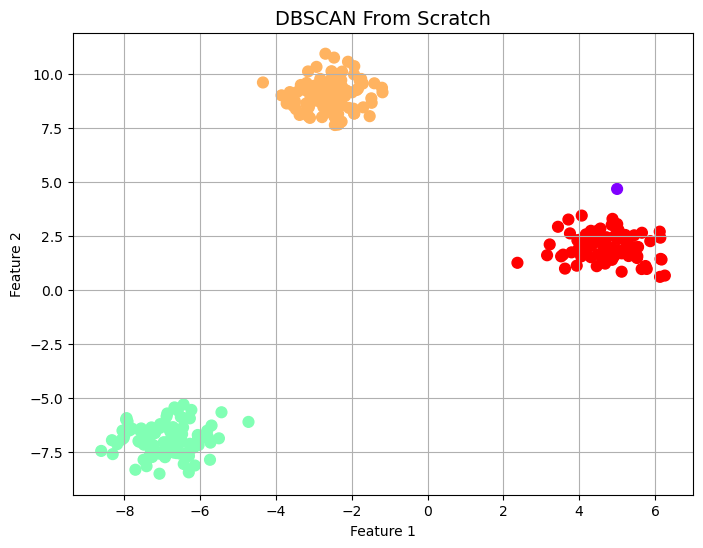

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# =========================================================
#               DBSCAN FROM SCRATCH
# =========================================================
# DBSCAN = Density-Based Spatial Clustering
#
# Idée :
# - regrouper les points proches
# - détecter automatiquement les clusters
# - identifier les points bruités (noise)
#
# Paramètres importants :
#
# 1. eps (ε)
#    rayon de voisinage
#
# 2. min_pts
#    nombre minimum de voisins
#
# Conditions mathématiques :
#
# Distance euclidienne : d(p,q) = √((x1-x2)² + (y1-y2)²)
#
# Voisinage epsilon :  Nε(p) = { q | d(p,q) ≤ ε }
#
# Point core : |Nε(p)| ≥ min_pts
# =========================================================

class DBSCAN_From_Scratch:

    def __init__(self, eps=0.8, min_pts=5):

        # ε : rayon de voisinage
        # Deux points sont voisins si :
        #
        # d(p,q) ≤ ε
        #
        # plus ε est grand :
        # → plus les clusters deviennent grands
        self.eps = eps

        # min_pts :
        # nombre minimum de voisins pour former un cluster
        #
        # si :
        # |Nε(p)| ≥ min_pts
        #
        # alors p est un core point
        self.min_pts = min_pts

        # labels :
        # stocke le numéro du cluster de chaque point
        #
        # -1 signifie :
        # bruit (noise)
        self.labels = None

        # visited :
        # tableau booléen
        #
        # True  → déjà traité
        # False → pas encore traité
        self.visited = None

        # identifiant des clusters
        #
        # cluster 1
        # cluster 2
        # cluster 3 ...
        self.cluster_id = 0

    # =====================================================
    # Distance euclidienne
    #
    # Formule :
    #
    # d(p,q) = √((x1-x2)² + (y1-y2)²)
    #
    # Exemple :
    #
    # p1 = (2,3)
    # p2 = (5,7)
    #
    # d = √((5-2)² + (7-3)²)
    # =====================================================
    def euclidean_distance(self, p1, p2):

        # différence entre coordonnées
        diff = p1 - p2

        # carré des différences
        squared = diff ** 2

        # somme des carrés
        summed = np.sum(squared)

        # racine carrée
        distance = np.sqrt(summed)

        return distance

    # =====================================================
    # Recherche des voisins
    #
    # Nε(p) = { q | d(p,q) ≤ ε }
    #
    # Cette fonction :
    # - parcourt tous les points
    # - calcule la distance
    # - conserve les points proches
    # =====================================================
    def get_neighbors(self, X, idx):

        # liste des voisins
        neighbors = []

        # parcourir tous les points du dataset
        for i in range(len(X)):

            # calcul distance entre :
            # point actuel et point i
            distance = self.euclidean_distance(X[idx], X[i])

            # condition du voisinage
            #
            # si distance ≤ ε
            # alors le point est voisin
            if distance <= self.eps:
                neighbors.append(i)

        return neighbors

    # =====================================================
    # Expansion du cluster
    #
    # Idée :
    #
    # - partir d’un core point
    # - ajouter ses voisins
    # - puis les voisins des voisins
    # - jusqu’à construire le cluster complet
    #
    # DBSCAN fonctionne comme une propagation
    # dans les zones denses
    # =====================================================
    def expand_cluster(self, X, idx, neighbors):

        # assigner le cluster au point de départ
        self.labels[idx] = self.cluster_id

        i = 0

        # parcourir tous les voisins
        while i < len(neighbors):

            # voisin actuel
            neighbor_idx = neighbors[i]

            # si le point n’a pas encore été traité
            if not self.visited[neighbor_idx]:

                # marquer comme visité
                self.visited[neighbor_idx] = True

                # récupérer ses voisins
                new_neighbors = self.get_neighbors(X, neighbor_idx)

                # vérifier si ce voisin est aussi un core point
                #
                # condition :
                #
                # |Nε(p)| ≥ min_pts
                if len(new_neighbors) >= self.min_pts:

                    # ajouter ses voisins
                    #
                    # cela permet :
                    # expansion progressive du cluster
                    neighbors += new_neighbors

            # si le point n’a pas encore de cluster
            if self.labels[neighbor_idx] == -1:

                # assigner cluster actuel
                self.labels[neighbor_idx] = self.cluster_id

            i += 1

    # =====================================================
    # Fonction principale DBSCAN
    #
    # Étapes :
    #
    # 1. Parcourir tous les points
    #
    # 2. Trouver les voisins
    #
    # 3. Vérifier :
    #
    #    |Nε(p)| < min_pts
    #
    #    → bruit
    #
    # 4. Sinon :
    #
    #    créer cluster
    #    puis expansion
    # =====================================================
    def fit(self, X):

        # conversion en tableau numpy
        X = np.array(X)

        # nombre total de points
        n = len(X)

        # initialisation des labels
        #
        # tous les points commencent à -1
        #
        # -1 = noise
        self.labels = np.full(n, -1)

        # aucun point visité au départ
        self.visited = np.zeros(n, dtype=bool)

        # parcourir tous les points
        for i in range(n):

            # si déjà traité → passer
            if self.visited[i]:
                continue

            # marquer comme visité
            self.visited[i] = True

            # récupérer voisins
            neighbors = self.get_neighbors(X, i)

            # =================================================
            # CAS 1 : BRUIT
            #
            # si :
            # |Nε(p)| < min_pts
            #
            # alors le point est noise
            # =================================================
            if len(neighbors) < self.min_pts:

                self.labels[i] = -1

            # =================================================
            # CAS 2 : CORE POINT
            #
            # création d’un nouveau cluster
            # =================================================
            else:

                # nouveau cluster
                self.cluster_id += 1

                # expansion du cluster
                self.expand_cluster(X, i, neighbors)

        return self.labels


# =========================================================
#              GÉNÉRATION DES DONNÉES
# =========================================================
# make_blobs :
# crée des données artificielles
#
# n_samples :
# nombre de points
#
# centers :
# nombre de groupes
#
# cluster_std :
# dispersion des points
# =========================================================

X, _ = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.7,
    random_state=42
)

# =========================================================
#              APPLICATION DBSCAN
# =========================================================

# création du modèle
model = DBSCAN_From_Scratch(

    # rayon de voisinage
    eps=0.9,

    # minimum voisins
    min_pts=5
)

# entraînement du modèle
labels = model.fit(X)

# =========================================================
#                    VISUALISATION
# =========================================================

# taille figure
plt.figure(figsize=(8,6))

# scatter plot :
# chaque couleur représente un cluster
plt.scatter(

    # coordonnées X
    X[:,0],

    # coordonnées Y
    X[:,1],

    # couleurs selon cluster
    c=labels,

    # palette de couleurs
    cmap='rainbow',

    # taille des points
    s=60
)

# titre
plt.title("DBSCAN From Scratch", fontsize=14)

# axe horizontal
plt.xlabel("Feature 1")

# axe vertical
plt.ylabel("Feature 2")

# grille
plt.grid(True)

# affichage du graphe
plt.show()